# Title: Does NS24122 carry CSF tracer deeper and further into the brain? - measured on tracer signal
# Author: Phillip Muza
# Date: 14/09/2026

`../NS24122_analysis/NS24122_tracer_penetration_analysis.ipynb` asked how deep and how far forward the tracer reaches by **counting voxels** of the pipeline's mask. That mask uses a per-slice adaptive threshold, so it measures the extent of locally-bright signal rather than the amount of tracer. This notebook asks the same two questions of the **amount of signal**, using the fixed per-animal threshold validated in `fixed_threshold_intensity.py` (background + 5 robust SDs on the raw 20 µm image, measured inside atlas ∩ tissue).

| | measured as | headline number |
|---|---|---|
| **Deeper** | distance below the brain's outer envelope, in atlas coordinates | **% of tracer signal deeper than 1 mm** |
| **Further** | position along the front-to-back axis | **% of tracer signal anterior to the front edge of the midbrain** |

Each animal's voxels are placed in atlas coordinates through its own deformation fields, so "1 mm deep" means the same anatomical place in every brain. Every voxel above the threshold contributes its raw intensity above that animal's background, instead of contributing 1. Both readouts are also computed by voxel count under the *same* fixed threshold, so the effect of weighting by intensity can be separated from the effect of changing the mask.

Absolute values will not match the earlier notebook: the fixed threshold is stricter than the pipeline's per-slice one (for an4 FITC, 0.42% of the brain vs 1.53%), so the two describe different voxel sets. The comparison that matters is the group difference, and Step 5 puts the three versions side by side.

**Groups:** Vehicle (7), NS24122 10 mg (7), NS24122 30 mg (6); an12, an14, an35 excluded. Each dose vs Vehicle, Welch's t-test with an exact permutation test alongside, Holm across the 8 headline tests (2 measures × 2 tracers × 2 doses).

In [1]:
# import libraries
import os
import itertools

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

parent_dir = r'E:\tracer_uptake\wt_mice\new_analysis_0926'
analysis_dir = os.path.join(parent_dir, 'NS24122_intensity')
pen_cache = os.path.join(analysis_dir, 'pen_cache')
coverage_outputs = os.path.join(parent_dir, 'NS24122_analysis', 'penetration_outputs')
output_dir = os.path.join(analysis_dir, 'outputs')
os.makedirs(output_dir, exist_ok=True)

VOXEL_MM = 0.02
DEPTH_THRESHOLD_MM = 1.0
TRACERS = ['FITC', 'TxR']
TREATMENT_ORDER = ['Vehicle', 'NS24122_10mg', 'NS24122_30mg']
CONTRASTS = [('NS24122_10mg', 'Vehicle'), ('NS24122_30mg', 'Vehicle')]
TREATMENT_COLORS = {'FITC': dict(zip(TREATMENT_ORDER, ['#74C476', '#238B45', '#00441B'])),
                    'TxR': dict(zip(TREATMENT_ORDER, ['#FC9272', '#CB181D', '#67000D']))}
TREATMENT_STYLE = {'Vehicle': '--', 'NS24122_10mg': '-.', 'NS24122_30mg': '-'}


def short(treatment):
    return treatment.replace('NS24122_', '')


reference = np.load(os.path.join(pen_cache, 'reference.npz'))
Y_PLANE = int(reference['y_plane'])
THALAMUS_PLANE = int(reference['thalamus_plane'])
DEPTH_EDGES = reference['depth_edges']
atlas_per_plane = reference['atlas_per_plane']

meta = pd.read_csv(os.path.join(analysis_dir, 'penetration_intensity_meta.csv'))
data_map = (pd.read_csv(r'E:\tracer_uptake\wt_mice\data_map.csv', encoding='utf-8-sig')
              .rename(columns={'blinded_number': 'animal_number'}).set_index('animal_number'))
animals = sorted(meta['animal_number'], key=lambda a: int(a[2:]))
treatment_of = data_map['treatment'].to_dict()
groups = {t: [a for a in animals if treatment_of[a] == t] for t in TREATMENT_ORDER}
hists = {animal: dict(np.load(os.path.join(pen_cache, f'{animal}.npz'))) for animal in animals}

for treatment, members in groups.items():
    print(f'{treatment} (n={len(members)}): {members}')
print(f'\nfront edge of the midbrain: plane {Y_PLANE} ({Y_PLANE * VOXEL_MM:.2f} mm); '
      f'caudal thalamus: plane {THALAMUS_PLANE} ({THALAMUS_PLANE * VOXEL_MM:.2f} mm)')

Vehicle (n=7): ['an4', 'an7', 'an17', 'an19', 'an21', 'an22', 'an24']
NS24122_10mg (n=7): ['an25', 'an26', 'an29', 'an30', 'an32', 'an33', 'an36']
NS24122_30mg (n=6): ['an2', 'an3', 'an6', 'an10', 'an13', 'an16']

front edge of the midbrain: plane 358 (7.16 mm); caudal thalamus: plane 429 (8.58 mm)


In [2]:
# Front-to-back range imaged in ALL animals, as in the coverage notebook: compare each animal's tissue
# voxels per atlas plane with the atlas's own, scaled by the animal's size over a central range
central = np.zeros(len(atlas_per_plane), bool)
central[int(3.0 / VOXEL_MM):int(7.0 / VOXEL_MM)] = True
rows = []
for animal in animals:
    per_plane = hists[animal]['brain_counts'].sum(axis=1)
    scale = per_plane[central].sum() / atlas_per_plane[central].sum()
    imaged = np.flatnonzero((atlas_per_plane > 0) & (per_plane >= 0.5 * scale * atlas_per_plane))
    rows.append({'animal': animal, 'treatment': treatment_of[animal],
                 'front_mm': imaged[0] * VOXEL_MM, 'back_mm': imaged[-1] * VOXEL_MM})
range_df = pd.DataFrame(rows)
FRONT_PLANE = int(round(range_df['front_mm'].max() / VOXEL_MM))
POSTERIOR_REF_PLANE = int(round(range_df['back_mm'].min() / VOXEL_MM))
common = slice(FRONT_PLANE, POSTERIOR_REF_PLANE + 1)
print(range_df.round(2).to_string(index=False))
print(f'\nrange imaged in all animals: {FRONT_PLANE * VOXEL_MM:.2f}-{POSTERIOR_REF_PLANE * VOXEL_MM:.2f} mm from the atlas front; '
      'both headline numbers are computed inside it')

animal    treatment  front_mm  back_mm
   an2 NS24122_30mg      0.90     9.92
   an3 NS24122_30mg      0.38     9.82
   an4      Vehicle      0.84     9.88
   an6 NS24122_30mg      0.70     9.70
   an7      Vehicle      0.82     9.90
  an10 NS24122_30mg      0.86     9.94
  an13 NS24122_30mg      0.32     9.72
  an16 NS24122_30mg      0.40     9.52
  an17      Vehicle      0.46     9.84
  an19      Vehicle      0.56     9.82
  an21      Vehicle      0.22     9.72
  an22      Vehicle      0.38     9.92
  an24      Vehicle      0.58    10.18
  an25 NS24122_10mg      0.74     9.82
  an26 NS24122_10mg      0.22     9.82
  an29 NS24122_10mg      0.68     9.90
  an30 NS24122_10mg      0.12     9.62
  an32 NS24122_10mg      0.46     9.92
  an33 NS24122_10mg      1.54    10.24
  an36 NS24122_10mg      0.22    10.28

range imaged in all animals: 1.54-9.52 mm from the atlas front; both headline numbers are computed inside it


In [3]:
def tracer_hist(animal, tracer, weighting):
    """(plane x depth) histogram of counted tracer, weighted by voxel count or by intensity."""
    h = hists[animal][f'{tracer}_in_{weighting}'].copy()
    shell = f'{tracer}_shell_{weighting}'
    if shell in hists[animal]:
        h = h + hists[animal][shell]
    return h


def pct_deeper(h, depth_mm=DEPTH_THRESHOLD_MM):
    """% of the tracer in h (restricted to the common range) at or below depth_mm."""
    by_depth = h[common].sum(axis=0)
    return 100 * by_depth[DEPTH_EDGES[:-1] >= depth_mm - 1e-9].sum() / by_depth.sum()


def pct_anterior(h, plane=Y_PLANE):
    """% of the tracer (within the common range) in atlas planes anterior to `plane`."""
    by_plane = h.sum(axis=1)
    return 100 * by_plane[FRONT_PLANE:plane].sum() / by_plane[common].sum()


def welch_summary(values, group_a, group_b):
    """Welch's t-test of group_a - group_b with the Welch-Satterthwaite 95% CI of the difference."""
    a, b = values[group_a].to_numpy(float), values[group_b].to_numpy(float)
    va, vb = a.var(ddof=1) / len(a), b.var(ddof=1) / len(b)
    se = np.sqrt(va + vb)
    df = (va + vb) ** 2 / (va ** 2 / (len(a) - 1) + vb ** 2 / (len(b) - 1))
    diff = a.mean() - b.mean()
    half = stats.t.ppf(0.975, df) * se
    return {'difference': diff, 'ci_low': diff - half, 'ci_high': diff + half,
            'p_welch': stats.ttest_ind(a, b, equal_var=False)[1]}


def exact_p(values, group_a, group_b):
    """Two-sided exact permutation p over every re-assignment of these animals to groups of the same sizes."""
    pooled = sorted(group_a + group_b, key=lambda x: int(x[2:]))
    observed = values[group_a].mean() - values[group_b].mean()
    null = [values[[x for x in pooled if x not in b]].mean() - values[list(b)].mean()
            for b in itertools.combinations(pooled, len(group_b))]
    return float(np.mean(np.abs(null) >= abs(observed) - 1e-12))


def per_animal_values(weighting, depth_mm=DEPTH_THRESHOLD_MM, plane=Y_PLANE):
    """Both headline numbers per animal and tracer, under one weighting."""
    rows = []
    for animal in animals:
        for tracer in TRACERS:
            h = tracer_hist(animal, tracer, weighting)
            rows.append({'animal': animal, 'treatment': treatment_of[animal], 'tracer': tracer,
                         'weighting': weighting, 'pct_deeper': pct_deeper(h, depth_mm),
                         'pct_anterior': pct_anterior(h, plane),
                         'total': h[common].sum()})
    return pd.DataFrame(rows)


def test_table(values_df, measures=(('pct_deeper', f'% deeper than {DEPTH_THRESHOLD_MM:g} mm'),
                                    ('pct_anterior', '% anterior to the midbrain'))):
    """Each dose vs Vehicle, per tracer and measure."""
    rows = []
    for tracer in TRACERS:
        t = values_df[values_df['tracer'] == tracer].set_index('animal')
        for column, label in measures:
            v = t[column]
            for treatment, reference_group in CONTRASTS:
                a, b = groups[treatment], groups[reference_group]
                rows.append({'tracer': tracer, 'measure': label, 'treatment': treatment,
                             'weighting': values_df['weighting'].iloc[0],
                             'Vehicle_mean': v[b].mean(), 'Vehicle_sem': v[b].sem(),
                             'dose_mean': v[a].mean(), 'dose_sem': v[a].sem(),
                             **welch_summary(v, a, b), 'p_exact': exact_p(v, a, b)})
    return pd.DataFrame(rows)


signal = per_animal_values('intensity')
counts = per_animal_values('counts')
headline = test_table(signal)
headline['p_welch_holm'] = multipletests(headline['p_welch'], method='holm')[1]
headline['p_exact_holm'] = multipletests(headline['p_exact'], method='holm')[1]

with pd.option_context('display.float_format', '{:.3f}'.format, 'display.width', 250):
    print('Per animal, signal-weighted:')
    print(signal.assign(order=signal['treatment'].map(TREATMENT_ORDER.index))
          .pivot(index=['order', 'treatment', 'animal'], columns='tracer', values=['pct_deeper', 'pct_anterior'])
          .droplevel('order').to_string())

Per animal, signal-weighted:
                    pct_deeper        pct_anterior       
tracer                    FITC    TxR         FITC    TxR
treatment    animal                                      
Vehicle      an17        6.898  6.326       53.793 27.401
             an19       21.984 11.153       53.447 43.317
             an21       10.133  4.979       83.053 56.556
             an22       12.320  8.092       72.445 59.220
             an24       21.154  5.825       80.082 63.392
             an4         8.773  7.641       76.913 61.851
             an7        16.384  8.027       80.528 43.686
NS24122_10mg an25       23.994 17.334       15.392 12.398
             an26       18.199 31.794       74.924 26.187
             an29       12.667  7.942       58.894 44.319
             an30       25.794 21.532       40.932 25.745
             an32       17.999 26.805       27.045 15.600
             an33        8.414  5.900       87.383 73.387
             an36       21.230  8.261      

## Deeper, and further - on signal

Three views per tracer, as in the coverage notebook: the profile across depth, the cumulative curve behind the headline number, and the headline itself with one dot per animal. Panel (a) is now intensity per tissue voxel rather than % coverage.

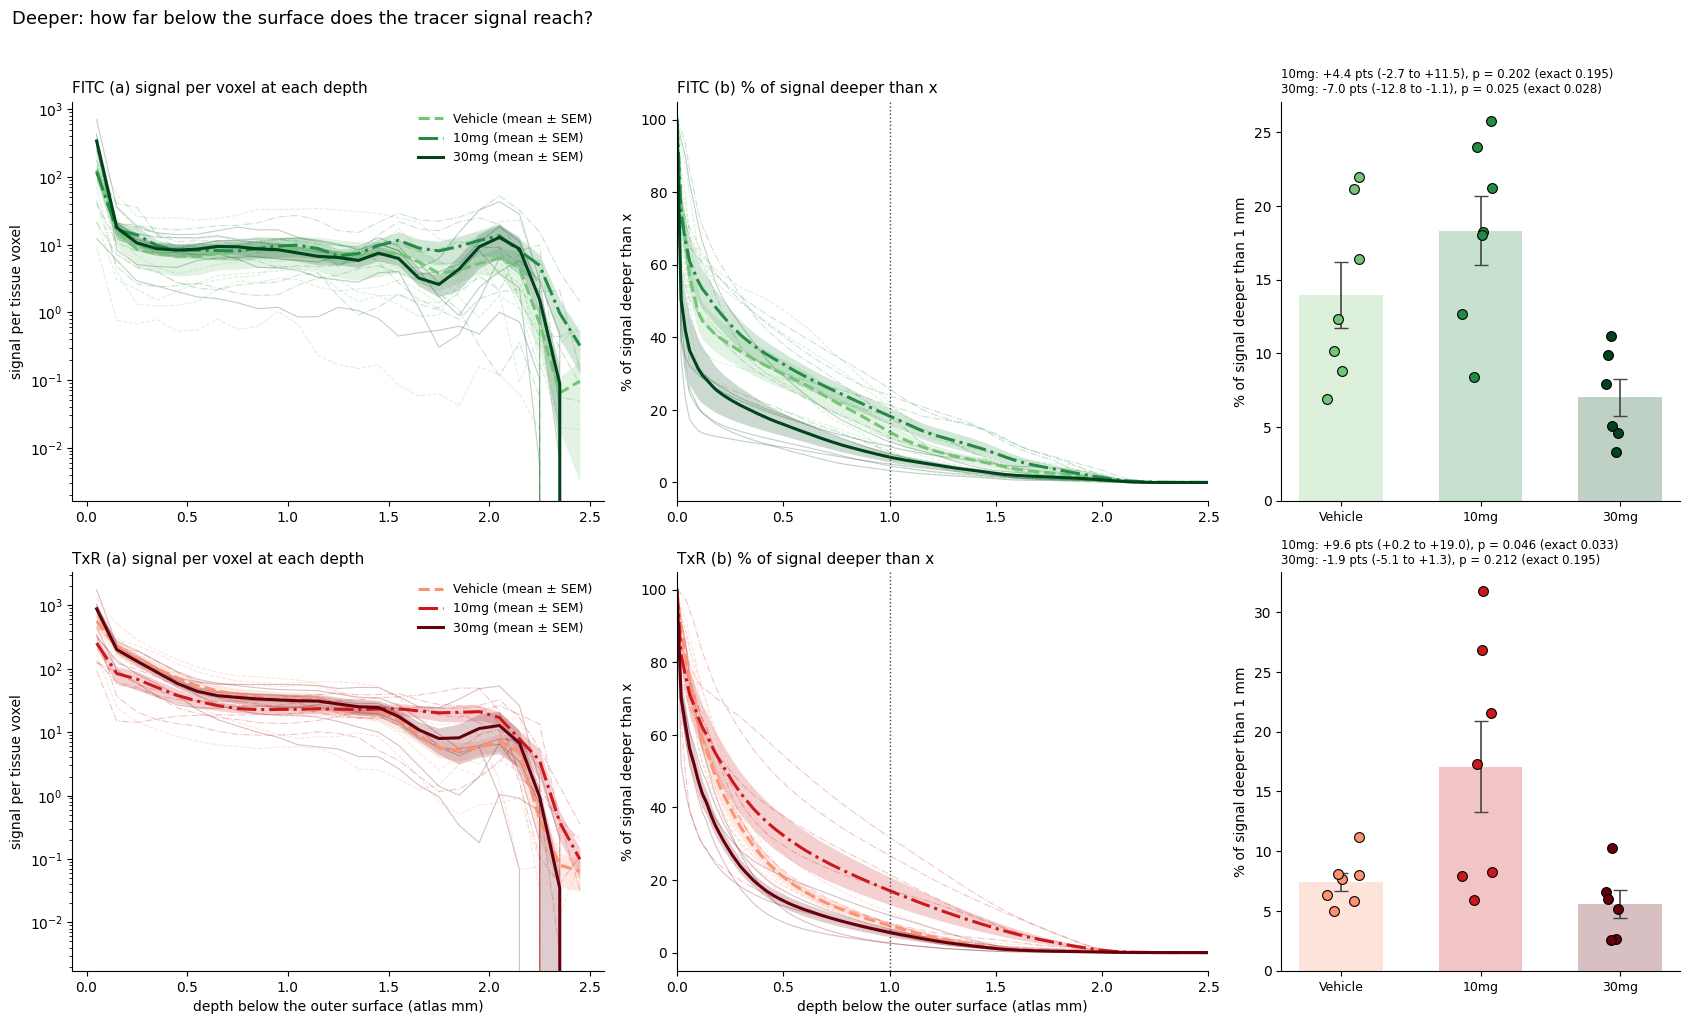

In [4]:
def group_curve(curves):
    """Mean and SEM per treatment of a dict animal -> 1D array."""
    out = {}
    for treatment in TREATMENT_ORDER:
        m = np.array([curves[a] for a in groups[treatment]])
        out[treatment] = (np.nanmean(m, axis=0), np.nanstd(m, axis=0, ddof=1) / np.sqrt(len(m)))
    return out


def plot_curves(ax, x, curves, tracer, ylabel, log=False):
    for animal in animals:
        ax.plot(x, curves[animal], color=TREATMENT_COLORS[tracer][treatment_of[animal]], alpha=0.25,
                linewidth=0.8, linestyle=TREATMENT_STYLE[treatment_of[animal]])
    for treatment, (mean, sem) in group_curve(curves).items():
        colour = TREATMENT_COLORS[tracer][treatment]
        ax.fill_between(x, mean - sem, mean + sem, color=colour, alpha=0.2, linewidth=0)
        ax.plot(x, mean, color=colour, linewidth=2.2, linestyle=TREATMENT_STYLE[treatment],
                label=f'{short(treatment)} (mean ± SEM)')
    if log:
        ax.set_yscale('log')
    ax.set_ylabel(ylabel, fontsize=10)
    sns.despine(ax=ax)


def plot_dots(ax, values, tracer, rows, ylabel):
    rng = np.random.default_rng(1)
    for x, treatment in enumerate(TREATMENT_ORDER):
        v = values.loc[groups[treatment]]
        ax.bar(x, v.mean(), width=0.6, color=TREATMENT_COLORS[tracer][treatment], alpha=0.25,
               yerr=v.sem(), capsize=5, error_kw={'elinewidth': 1.2, 'ecolor': '#444444'})
        ax.scatter(x + rng.uniform(-0.14, 0.14, len(v)), v, s=50, color=TREATMENT_COLORS[tracer][treatment],
                   edgecolor='black', linewidth=0.8, zorder=3)
    ax.set_xticks(range(len(TREATMENT_ORDER)))
    ax.set_xticklabels([short(t) for t in TREATMENT_ORDER], fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title('\n'.join(f"{short(r['treatment'])}: {r['difference']:+.1f} pts "
                           f"({r['ci_low']:+.1f} to {r['ci_high']:+.1f}), p = {r['p_welch']:.3f} (exact {r['p_exact']:.3f})"
                           for _, r in rows.iterrows()), fontsize=8.5, loc='left')
    sns.despine(ax=ax)


SHELL_MM, bins_per_shell = 0.1, 5
shell_mid = np.arange(0, 2.5, SHELL_MM) + SHELL_MM / 2
fine_depth = DEPTH_EDGES[:-1]

fig, axes = plt.subplots(len(TRACERS), 3, figsize=(17, 5.2 * len(TRACERS)), gridspec_kw={'width_ratios': [1.2, 1.2, 0.9]})
for r, tracer in enumerate(TRACERS):
    density, exceed = {}, {}
    for animal in animals:
        s = tracer_hist(animal, tracer, 'intensity')[common].sum(axis=0)
        b = hists[animal]['brain_counts'][common].sum(axis=0)
        n = len(shell_mid)
        s_shell = s[:n * bins_per_shell].reshape(n, bins_per_shell).sum(axis=1)
        b_shell = b[:n * bins_per_shell].reshape(n, bins_per_shell).sum(axis=1)
        density[animal] = np.where(b_shell > 0, s_shell / np.maximum(b_shell, 1), np.nan)
        exceed[animal] = 100 * (s.sum() - np.concatenate([[0], np.cumsum(s)[:-1]])) / s.sum()
    plot_curves(axes[r, 0], shell_mid, density, tracer, 'signal per tissue voxel', log=True)
    axes[r, 0].set_title(f'{tracer} (a) signal per voxel at each depth', fontsize=11, loc='left')
    plot_curves(axes[r, 1], fine_depth, exceed, tracer, '% of signal deeper than x')
    axes[r, 1].axvline(DEPTH_THRESHOLD_MM, color='#444444', linewidth=1, linestyle=':')
    axes[r, 1].set_xlim(0, 2.5)
    axes[r, 1].set_title(f'{tracer} (b) % of signal deeper than x', fontsize=11, loc='left')
    v = signal[signal['tracer'] == tracer].set_index('animal')['pct_deeper']
    plot_dots(axes[r, 2], v, tracer, headline[(headline['tracer'] == tracer) & headline['measure'].str.contains('deeper')],
              f'% of signal deeper than {DEPTH_THRESHOLD_MM:g} mm')
    axes[r, 0].legend(frameon=False, fontsize=9)
for ax in axes[-1, :2]:
    ax.set_xlabel('depth below the outer surface (atlas mm)', fontsize=10)
fig.suptitle('Deeper: how far below the surface does the tracer signal reach?', x=0.01, ha='left', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

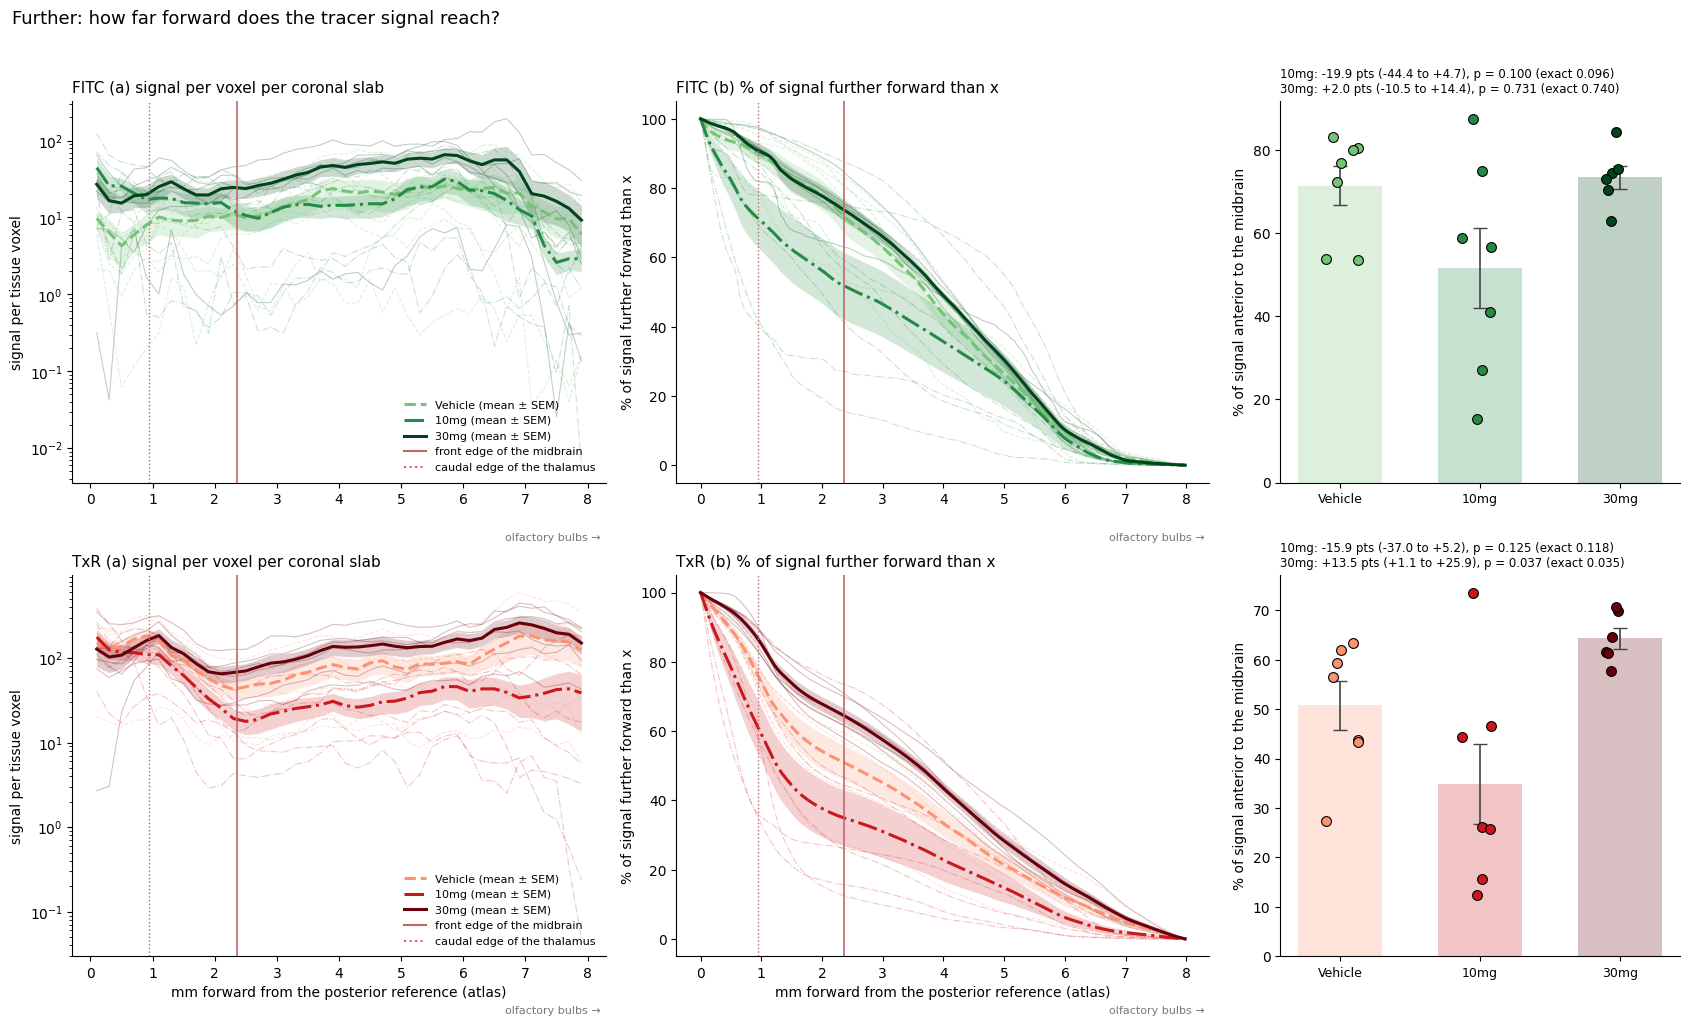

Headline results, signal-weighted (Holm across the 8 tests):
tracer                    measure    treatment  Vehicle_mean  dose_mean  difference  ci_low  ci_high  p_welch  p_exact  p_welch_holm  p_exact_holm
  FITC         % deeper than 1 mm NS24122_10mg        13.950     18.328       4.379  -2.697   11.454    0.202    0.195         0.607         0.584
  FITC         % deeper than 1 mm NS24122_30mg        13.950      6.997      -6.952 -12.820   -1.084    0.025    0.028         0.200         0.224
  FITC % anterior to the midbrain NS24122_10mg        71.466     51.615     -19.851 -44.362    4.660    0.100    0.096         0.499         0.478
  FITC % anterior to the midbrain NS24122_30mg        71.466     73.434       1.968 -10.499   14.436    0.731    0.740         0.731         0.740
   TxR         % deeper than 1 mm NS24122_10mg         7.435     17.081       9.647   0.249   19.044    0.046    0.033         0.274         0.228
   TxR         % deeper than 1 mm NS24122_30mg         7.

In [5]:
SLAB_PLANES = 10
planes_common = np.arange(FRONT_PLANE, POSTERIOR_REF_PLANE + 1)
y_forward = (POSTERIOR_REF_PLANE - Y_PLANE) * VOXEL_MM
th_forward = (POSTERIOR_REF_PLANE - THALAMUS_PLANE) * VOXEL_MM

fig, axes = plt.subplots(len(TRACERS), 3, figsize=(17, 5.2 * len(TRACERS)), gridspec_kw={'width_ratios': [1.2, 1.2, 0.9]})
for r, tracer in enumerate(TRACERS):
    slab, exceed = {}, {}
    for animal in animals:
        s = tracer_hist(animal, tracer, 'intensity').sum(axis=1)[planes_common][::-1]
        b = hists[animal]['brain_counts'].sum(axis=1)[planes_common][::-1]
        n = len(s) // SLAB_PLANES
        s_slab = s[:n * SLAB_PLANES].reshape(n, SLAB_PLANES).sum(axis=1)
        b_slab = b[:n * SLAB_PLANES].reshape(n, SLAB_PLANES).sum(axis=1)
        slab[animal] = np.where(b_slab > 0, s_slab / np.maximum(b_slab, 1), np.nan)
        exceed[animal] = 100 * (s.sum() - np.concatenate([[0], np.cumsum(s)[:-1]])) / s.sum()
    slab_mid = (np.arange(n) + 0.5) * SLAB_PLANES * VOXEL_MM
    plot_curves(axes[r, 0], slab_mid, slab, tracer, 'signal per tissue voxel', log=True)
    plot_curves(axes[r, 1], np.arange(len(s)) * VOXEL_MM, exceed, tracer, '% of signal further forward than x')
    for ax in axes[r, :2]:
        ax.axvline(y_forward, color='#C1666B', linewidth=1.2)
        ax.axvline(th_forward, color='#C1666B', linewidth=1, linestyle=':')
        ax.text(0.99, -0.13, 'olfactory bulbs →', transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#777777')
    axes[r, 0].set_title(f'{tracer} (a) signal per voxel per coronal slab', fontsize=11, loc='left')
    axes[r, 1].set_title(f'{tracer} (b) % of signal further forward than x', fontsize=11, loc='left')
    v = signal[signal['tracer'] == tracer].set_index('animal')['pct_anterior']
    plot_dots(axes[r, 2], v, tracer, headline[(headline['tracer'] == tracer) & headline['measure'].str.contains('anterior')],
              '% of signal anterior to the midbrain')
    handles, _ = axes[r, 0].get_legend_handles_labels()
    handles += [Line2D([0], [0], color='#C1666B', label='front edge of the midbrain'),
                Line2D([0], [0], color='#C1666B', ls=':', label='caudal edge of the thalamus')]
    axes[r, 0].legend(handles=handles, frameon=False, fontsize=8, loc='lower right')
for ax in axes[-1, :2]:
    ax.set_xlabel('mm forward from the posterior reference (atlas)', fontsize=10)
fig.suptitle('Further: how far forward does the tracer signal reach?', x=0.01, ha='left', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

print('Headline results, signal-weighted (Holm across the 8 tests):')
with pd.option_context('display.float_format', '{:.3f}'.format, 'display.width', 250):
    print(headline[['tracer', 'measure', 'treatment', 'Vehicle_mean', 'dose_mean', 'difference', 'ci_low', 'ci_high',
                    'p_welch', 'p_exact', 'p_welch_holm', 'p_exact_holm']].to_string(index=False))

## Three versions of the same two questions

The same headline numbers under each way of defining "tracer": the pipeline's per-slice adaptive mask (the earlier notebook), the fixed per-animal threshold counted by voxel, and the fixed threshold weighted by intensity. Differences between the first two come from the mask; between the last two, from weighting by amount.

In [6]:
comparison = pd.concat([test_table(counts).assign(weighting='counts, fixed threshold'),
                        headline.assign(weighting='signal, fixed threshold')], ignore_index=True)
old = pd.read_csv(os.path.join(coverage_outputs, 'penetration_headline_tests.csv'))
old = old.rename(columns={'reference_mean': 'Vehicle_mean', 'treatment_mean': 'dose_mean'})
old['measure'] = old['measure'].str.replace('% of tracer ', '% ', regex=False).str.replace(' 1 mm', ' 1 mm', regex=False)
old['weighting'] = 'counts, pipeline per-slice mask'
keep = ['tracer', 'measure', 'treatment', 'weighting', 'Vehicle_mean', 'dose_mean', 'difference', 'p_welch', 'p_exact']
comparison = pd.concat([old[keep], comparison[keep]], ignore_index=True)
comparison['measure'] = comparison['measure'].str.replace('deeper than 1 mm', 'deeper than 1 mm', regex=False)
order = {'counts, pipeline per-slice mask': 0, 'counts, fixed threshold': 1, 'signal, fixed threshold': 2}
comparison = comparison.sort_values(['tracer', 'measure', 'treatment', 'weighting'],
                                    key=lambda s: s.map(order) if s.name == 'weighting' else s)
with pd.option_context('display.float_format', '{:.3f}'.format, 'display.width', 250):
    print(comparison.to_string(index=False))

tracer                    measure    treatment                       weighting  Vehicle_mean  dose_mean  difference  p_welch  p_exact
  FITC % anterior to the midbrain NS24122_10mg counts, pipeline per-slice mask        69.865     64.484      -5.381    0.149    0.137
  FITC % anterior to the midbrain NS24122_10mg         counts, fixed threshold        67.196     48.560     -18.636    0.099    0.099
  FITC % anterior to the midbrain NS24122_10mg         signal, fixed threshold        71.466     51.615     -19.851    0.100    0.096
  FITC % anterior to the midbrain NS24122_30mg counts, pipeline per-slice mask        69.865     73.027       3.162    0.187    0.189
  FITC % anterior to the midbrain NS24122_30mg         counts, fixed threshold        67.196     70.578       3.383    0.611    0.619
  FITC % anterior to the midbrain NS24122_30mg         signal, fixed threshold        71.466     73.434       1.968    0.731    0.740
  FITC         % deeper than 1 mm NS24122_10mg counts, pipelin

In [7]:
# Export
signal.to_csv(os.path.join(output_dir, 'penetration_signal_per_animal.csv'), index=False)
counts.to_csv(os.path.join(output_dir, 'penetration_counts_per_animal.csv'), index=False)
headline.to_csv(os.path.join(output_dir, 'penetration_signal_headline_tests.csv'), index=False)
comparison.to_csv(os.path.join(output_dir, 'penetration_metric_comparison.csv'), index=False)
range_df.to_csv(os.path.join(output_dir, 'penetration_signal_imaged_range.csv'), index=False)
print(f'Exported 5 tables to {output_dir}')

Exported 5 tables to E:\tracer_uptake\wt_mice\new_analysis_0926\NS24122_intensity\outputs
